In [1]:
import pandas as pd
from scipy.io import loadmat
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import griddata

In [21]:
data = loadmat(r"C:\WINDLAB_SUMMER\TPU_TEST_FILES\T213_4_030_1.mat")


# 1. Flip the location data so it's a table
loc_matrix = data['Location_of_measured_points']
loc_df = pd.DataFrame(loc_matrix.T, columns=['X', 'Y', 'Point_No', 'Face_No'])

# 2. Extract the pressure time-series
pressure_df = pd.DataFrame(data['Wind_pressure_coefficients'])

print(f"Total Taps: {len(loc_df)}")
print(f"Total Timesteps: {len(pressure_df)}")

print(loc_df.iloc[41])

Total Taps: 360
Total Timesteps: 32768
X            0.2300
Y            0.2625
Point_No    42.0000
Face_No      2.0000
Name: 41, dtype: float64


In [ ]:
plt.figure(figsize=(12, 6))

# 2. Plot the taps as blue crosses
plt.scatter(loc_df['X'], loc_df['Y'], marker='+', color='blue', s=100, linewidth=1)

# 3. Iterate through the dataframe to label each tap with its 'Point_No'
for index, row in loc_df.iterrows():
    point_num = int(row['Point_No'])
    x_val = row['X']
    y_val = row['Y']
    
    # Offset the text slightly down and to the right so it doesn't overlap the cross
    plt.text(x_val + 0.003, y_val - 0.003, str(point_num), 
             color='black', fontsize=10, ha='left', va='top')

# 4. Add the vertical dashed lines separating the faces/sections (at X = 0.1, 0.2, 0.3)
for v_line in [0.1, 0.2, 0.3]:
    plt.axvline(x=v_line, color='blue', linestyle='--', alpha=0.5)

# 5. Lock the axes limits to perfectly match the original MATLAB plot
plt.xlim(0, 0.4)
plt.ylim(0, 0.2)

# 6. Add the exact titles and axis labels
plt.title("Channels position", fontweight='bold', fontsize=12)
plt.xlabel("Horizontal Direction /m", fontsize=11)
plt.ylabel("Vertical Direction /m", fontsize=11)

# Show the fully reconstructed plot
plt.tight_layout()
plt.show()

TypeError: type numpy.ndarray doesn't define __round__ method

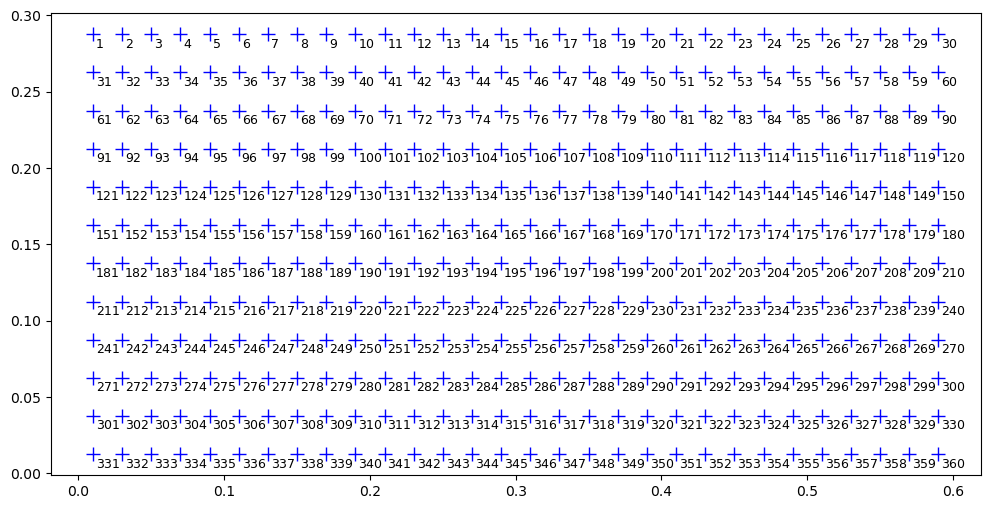

In [ ]:
def get_channel_plot(loc_df, pressure_df):
        plt.figure(figsize=(12, 6))

        # 2. MATCH SIZES: Cap the location coordinates to the exact number of active channels
        total_active_channels = pressure_df.shape[1] # Number of columns in pressure matrix (200)
        active_loc_df = loc_df.head(total_active_channels).copy()

        # 3. Double-check column mapping if things look upside down:
        # If X and Y are swapped in the source matrix, flip them here:
        # x_coords = active_loc_df['Y'] 
        # y_coords = active_loc_df['X']
        x_coords = active_loc_df['X']
        y_coords = active_loc_df['Y']

        # Plot the active taps as blue crosses
        plt.scatter(x_coords, y_coords, marker='+', color='blue', s=100, linewidth=1)

        # 4. Iterate ONLY through the active capped dataframe
        for index, row in active_loc_df.iterrows():
            point_num = int(row['Point_No'])
            x_val = row['X']
            y_val = row['Y']
            
            # Offset the text slightly down and to the right so it doesn't overlap
            plt.text(x_val + 0.002, y_val - 0.002, str(point_num), 
                     color='black', fontsize=9, ha='left', va='top')

        # Add the vertical dashed lines separating sections

        # 1. Sort the taps horizontally from left to right
        sorted_loc = active_loc_df.sort_values(by='X')

        # 2. Track where the Face Number changes from one row to the next
        face_changes = sorted_loc['Face_No'].ne(sorted_loc['Face_No'].shift())
        
        # 3. Extract the exact X-coordinates where those shifts happen
        # We skip the very first point (index 0) because that's just the outer left wall
        boundary_xs = sorted_loc[face_changes]['X'].values[1:]

        # 4. Draw the dashed boundary lines exactly at the structural seam transitions
        for v_line in boundary_xs:

            snapped_line = round(v_line, 1)

            plt.axvline(x=snapped_line, color='blue', linestyle='--', alpha=0.5)

        # Lock the axes limits perfectly to the original geometry bounds
        x_min, x_max = x_coords.min(), x_coords.max()
        y_min, y_max = y_coords.min(), y_coords.max()
        
        x_buffer = (x_max - x_min) * 0.1 if x_max != x_min else 0.05
        y_buffer = (y_max - y_min) * 0.1 if y_max != y_min else 0.05

        plt.xlim(max(0, x_min - x_buffer), x_max + x_buffer)
        plt.ylim(max(0, y_min - y_buffer), y_max + y_buffer)

        plt.title("Channels position", fontweight='bold', fontsize=12)
        plt.xlabel("Horizontal Direction /m", fontsize=11)
        plt.ylabel("Vertical Direction /m", fontsize=11)

        plt.tight_layout()
        plt.show()

get_channel_plot(loc_df, pressure_df)

In [4]:
print(pressure_df.T.head(15))

       0         1         2         3         4         5         6      \
0   0.748062  0.593907  0.442193  0.514281  0.578173  0.682314  0.769017   
1   0.892962  0.918450  0.934309  0.920288  0.963100  1.015618  1.096062   
2   1.056081  1.156595  1.134174  1.122646  1.069815  1.113395  1.216313   
3   1.264518  1.347174  1.279148  1.233254  1.155316  1.102785  1.049452   
4   1.261408  1.288911  1.164496  1.078816  0.899362  0.850701  0.935978   
5   1.255394  1.269665  1.099743  1.070362  0.939126  0.885522  0.924154   
6   1.276417  1.284267  1.131980  1.099845  0.930041  0.860598  0.887044   
7   1.313560  1.397348  1.271461  1.315987  1.154198  1.054071  1.014099   
8   1.153297  1.317680  1.282249  1.311296  1.177679  1.035498  0.960562   
9   0.799086  0.973958  0.921242  1.119398  1.042649  0.926950  0.908961   
10 -1.986749 -2.068051 -2.181667 -2.292483 -2.012393 -1.711849 -1.545591   
11 -1.326175 -0.965988 -1.022701 -0.810178 -1.470273 -1.727637 -1.579213   
12 -0.777671

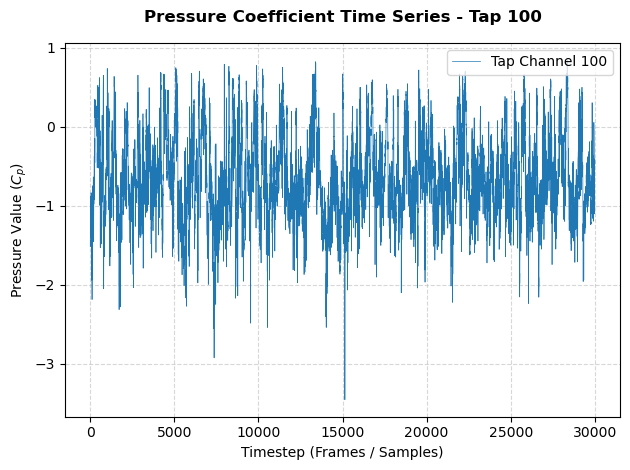

In [5]:
def get_timeseries_plot(pressure_df, tap_no, time_a, time_b):
    tap_idx = int(tap_no)
    start_idx = int(time_a)
    end_idx = int(time_b)


    pressure_tap_no = pressure_df[tap_idx]

    sliced_pressure = pressure_tap_no.iloc[start_idx: end_idx]

    plt.plot(
        sliced_pressure.index, 
        sliced_pressure.values, 
        color='#1f77b4', 
        linewidth=0.5, 
        label=f'Tap Channel {tap_no}'
    )

    plt.title(f'Pressure Coefficient Time Series - Tap {tap_no}', fontsize=12, fontweight='bold', pad=15)
    plt.xlabel('Timestep (Frames / Samples)', fontsize=10)
    plt.ylabel('Pressure Value ($C_p$)', fontsize=10)

    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend(loc='upper right')

    plt.tight_layout()

    plt.show()

get_timeseries_plot(pressure_df, 100, 1, 30000)

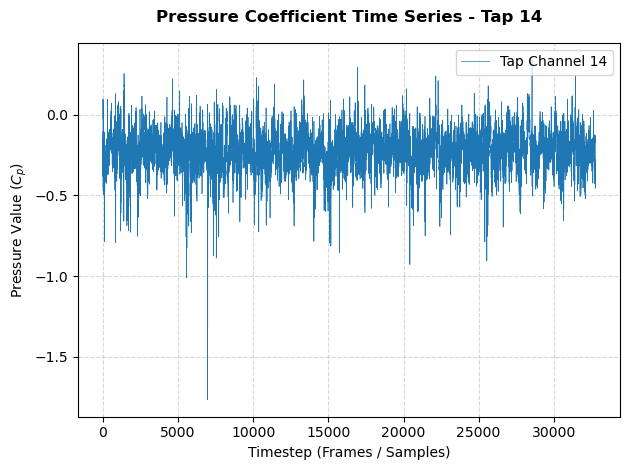

In [6]:
def view_all_steps(pressure_df, tap_no):
    tap_idx = int(tap_no)

    pressure_at_tap = pressure_df[tap_idx]


    plt.plot(
        pressure_at_tap.index, 
        pressure_at_tap.values, 
        color='#1f77b4', 
        linewidth=0.5, 
        label=f'Tap Channel {tap_no}'
    )

    
    plt.title(f'Pressure Coefficient Time Series - Tap {tap_no}', fontsize=12, fontweight='bold', pad=15)
    plt.xlabel('Timestep (Frames / Samples)', fontsize=10)
    plt.ylabel('Pressure Value ($C_p$)', fontsize=10)

    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend(loc='upper right')

    plt.tight_layout()

    plt.show()

view_all_steps(pressure_df, 14)



In [7]:
min_val = pressure_df[14].idxmin()
print(min_val)

6963


In [8]:
mean_cp_series = pressure_df.mean(axis = 0)
mean_cp_df = mean_cp_series.reset_index()
mean_cp_df.columns = ['Tap no.', 'mean_cp']

print(mean_cp_df)

     Tap no.   mean_cp
0          0  0.038071
1          1  0.225590
2          2  0.288896
3          3  0.329517
4          4  0.360988
..       ...       ...
355      355 -0.636432
356      356 -0.597553
357      357 -0.567640
358      358 -0.555531
359      359 -0.541262

[360 rows x 2 columns]


In [9]:
all_means = mean_cp_df['mean_cp'].values
num_taps = len(loc_df)
matched_means = all_means[:num_taps]

# 4. Paste it directly into the coordinate DataFrame
loc_df['mean_cp'] = matched_means

print(f"Successfully mapped {len(matched_means)} mean Cp values to the coordinates.")
#print(mean_cp_df)
print(loc_df)


Successfully mapped 360 mean Cp values to the coordinates.
        X       Y  Point_No  Face_No   mean_cp
0    0.01  0.2875       1.0      1.0  0.038071
1    0.03  0.2875       2.0      1.0  0.225590
2    0.05  0.2875       3.0      1.0  0.288896
3    0.07  0.2875       4.0      1.0  0.329517
4    0.09  0.2875       5.0      1.0  0.360988
..    ...     ...       ...      ...       ...
355  0.51  0.0125     356.0      4.0 -0.636432
356  0.53  0.0125     357.0      4.0 -0.597553
357  0.55  0.0125     358.0      4.0 -0.567640
358  0.57  0.0125     359.0      4.0 -0.555531
359  0.59  0.0125     360.0      4.0 -0.541262

[360 rows x 5 columns]


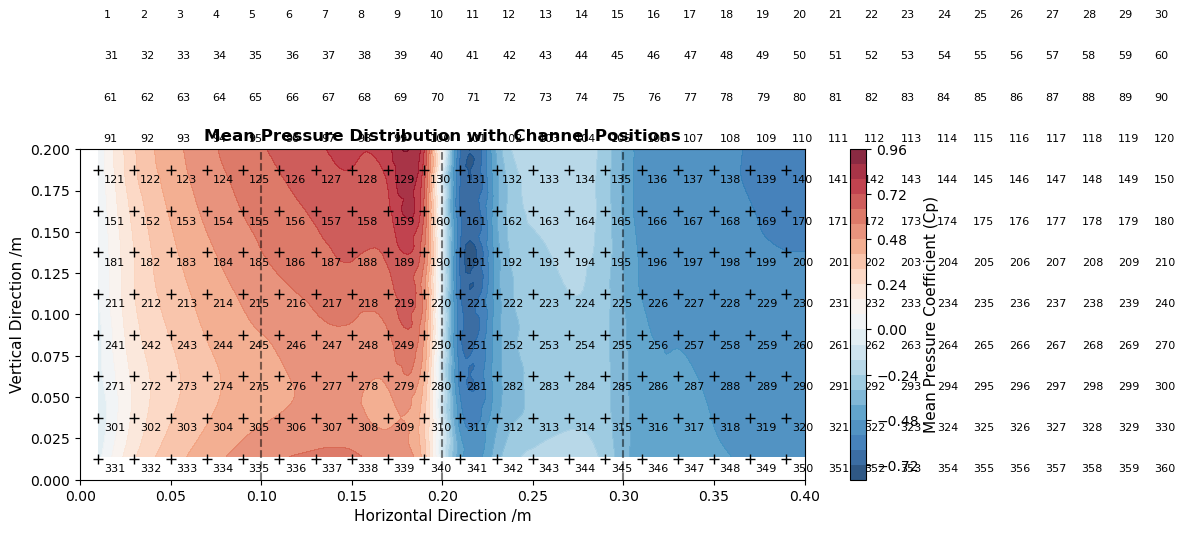

In [12]:
grid_x, grid_y = np.mgrid[0:0.4:200j, 0:0.2:100j]

# 2. Interpolate the scattered pressure data onto our new dense grid
# Change 'Mean_Cp' to whatever your actual pressure column is named!
grid_z = griddata((loc_df['X'], loc_df['Y']), loc_df['mean_cp'], (grid_x, grid_y), method='cubic')

# 3. Set up the figure
plt.figure(figsize=(12, 6))

# 4. Plot the smooth color contour map
# levels=20 gives 20 smooth color bands. 'RdBu_r' is the classic Red (high) / Blue (low) aerodynamic map
contour = plt.contourf(grid_x, grid_y, grid_z, levels=20, cmap='RdBu_r', alpha=0.85)

# Add a colorbar legend to the right side
cbar = plt.colorbar(contour)
cbar.set_label('Mean Pressure Coefficient (Cp)', fontsize=11)

# 5. Overlay the original tap locations as black crosses so they stand out against the color
plt.scatter(loc_df['X'], loc_df['Y'], marker='+', color='black', s=60, linewidth=1)

# Overlay the tap numbers (Made slightly smaller so it doesn't clutter the colors)
for index, row in loc_df.iterrows():
    plt.text(row['X'] + 0.003, row['Y'] - 0.003, str(int(row['Point_No'])), 
             color='black', fontsize=8, ha='left', va='top')

# 6. Add the vertical dashed lines back
for v_line in [0.1, 0.2, 0.3]:
    plt.axvline(x=v_line, color='black', linestyle='--', alpha=0.5)

# 7. Lock the axes limits perfectly to the original geometry
plt.xlim(0, 0.4)
plt.ylim(0, 0.2)

# 8. Add Titles and Labels
plt.title("Mean Pressure Distribution with Channel Positions", fontweight='bold', fontsize=12)
plt.xlabel("Horizontal Direction /m", fontsize=11)
plt.ylabel("Vertical Direction /m", fontsize=11)

# Show the plot
plt.tight_layout()
plt.show()  